# Mid-term Progress Report Graphs

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# setup paths
DATA_DIR = r"C:\Users\sahin\OneDrive\Belgeler\programming\economy-thesis\data"
OUT_DIR = r"C:\Users\sahin\OneDrive\Belgeler\programming\economy-thesis\report\Figures"

if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)

# set global plotting styles for academic readability
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "Arial",
    "font.size": 11,
})

In [12]:
def load_tuik_import_data():
    """Reads and concatenates TUIK Chapter 27 import data from 2013-2026."""
    def _load_single_excel(filepath):
        df = pd.read_excel(filepath, header=None)
        header_idx = df[df[0] == "Year"].index[0]
        df.columns = ["Year", "Month", "Chapter", "ChapterName", "Export_USD", "Import_USD"]
        df = df.iloc[header_idx + 1:].copy()
        df = df[df["Chapter"].astype(str).str.strip() == "27"].copy()
        df["Year"] = df["Year"].ffill().astype(int)
        df["Month"] = df["Month"].astype(int)
        df["Import_USD"] = pd.to_numeric(df["Import_USD"], errors="coerce")
        df["date"] = pd.to_datetime(df[["Year", "Month"]].assign(Day=1))
        return df[["date", "Import_USD"]]

    tuik_files = [
        "tuik-foreigntrade-2013-2017.xlsx",
        "tuik-foreigntrade-2018-2022.xlsx",
        "tuik-foreigntrade-2023-2026.xlsx",
    ]
    tuik = pd.concat([_load_single_excel(os.path.join(DATA_DIR, f)) for f in tuik_files], ignore_index=True)
    tuik.sort_values("date", inplace=True)
    tuik["Import_B"] = tuik["Import_USD"] / 1e9
    return tuik[tuik["date"] >= "2013-01-01"]

def load_fred_price_data(filename, col_name):
    """Loads FRED monthly price data and formats the date column."""
    df = pd.read_csv(os.path.join(DATA_DIR, filename), parse_dates=["observation_date"])
    df.rename(columns={"observation_date": "date", df.columns[1]: col_name}, inplace=True)
    df.dropna(subset=[col_name], inplace=True)
    return df[df["date"] >= "2013-01-01"]

# Load data globally for the plotting functions
df_imports = load_tuik_import_data()
df_gas = load_fred_price_data("PNGASEUUSDM.csv", "price_usd")
df_oil = load_fred_price_data("POILBREUSDM.csv", "price_usd")

In [13]:
df_imports.head(20)

,date,Import_USD,Import_B
48,2013-01-01,4846204313,4.846204
49,2013-02-01,4832146841,4.832147
50,2013-03-01,4510633001,4.510633
51,2013-04-01,4827625645,4.827626
52,2013-05-01,5096309934,5.096310
53,2013-06-01,4244592221,4.244592
54,2013-07-01,4886120316,4.886120
55,2013-08-01,4705456782,4.705457
56,2013-09-01,5090574817,5.090575
57,2013-10-01,4578489699,4.578490


In [14]:
df_oil.head(10)

,date,price_usd
120,2013-01-01,112.527826
121,2013-02-01,116.488000
122,2013-03-01,109.585714
123,2013-04-01,102.960000
124,2013-05-01,102.980435
125,2013-06-01,103.358500
126,2013-07-01,107.779565
127,2013-08-01,111.058182
128,2013-09-01,111.962857
129,2013-10-01,109.618696


## Türkiye Energy Imports vs. EU Natural Gas Prices

Saved C:\Users\sahin\OneDrive\Belgeler\programming\economy-thesis\report\Figures\price_vs_imports_gas.png


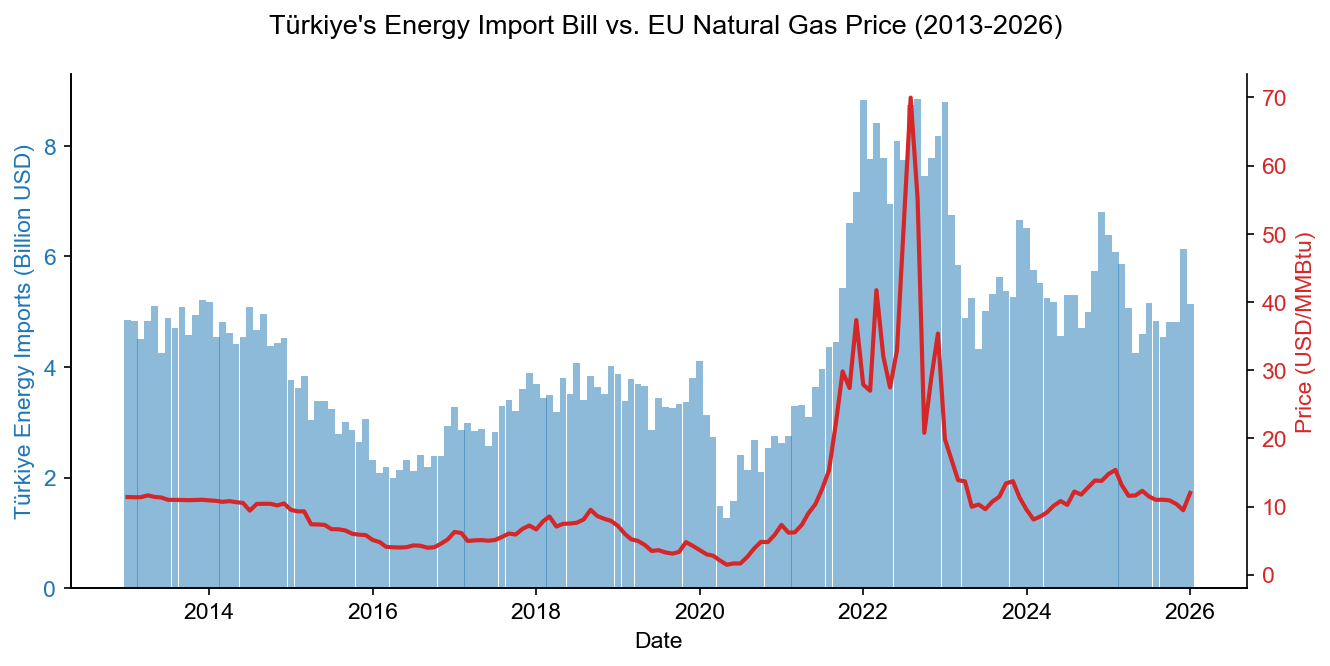

In [15]:
def plot_imports_vs_price(df_imports, df_price, title, ylabel_price, color_price, out_filename):
    """Generates a dual-axis plot comparing Türkiye's imports to a global benchmark price."""
    fig, ax1 = plt.subplots(figsize=(9, 4.5))

    color1 = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Türkiye Energy Imports (Billion USD)', color=color1)
    ax1.bar(df_imports['date'], df_imports['Import_B'], width=30, color=color1, alpha=0.5, label="Import Bill (LHS)")
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()  # instantiate a second axes sharing the x-axis
    ax2.set_ylabel(ylabel_price, color=color_price)
    ax2.plot(df_price['date'], df_price['price_usd'], color=color_price, linewidth=2, label=f"{title} (RHS)")
    ax2.tick_params(axis='y', labelcolor=color_price)
    ax2.spines['right'].set_visible(True)

    fig.suptitle(f"Türkiye's Energy Import Bill vs. {title} (2013-2026)", fontsize=13)
    fig.tight_layout()

    out_path = os.path.join(OUT_DIR, out_filename)
    plt.savefig(out_path, format="png", bbox_inches='tight')
    print(f"Saved {out_path}")
    plt.show()

# Generate Gas Graph
plot_imports_vs_price(df_imports, df_gas, "EU Natural Gas Price", "Price (USD/MMBtu)", "tab:red", "price_vs_imports_gas.png")

## Figure 2: Türkiye Energy Imports vs. Brent Crude Oil Prices

Saved C:\Users\sahin\OneDrive\Belgeler\programming\economy-thesis\report\Figures\price_vs_imports_oil.png


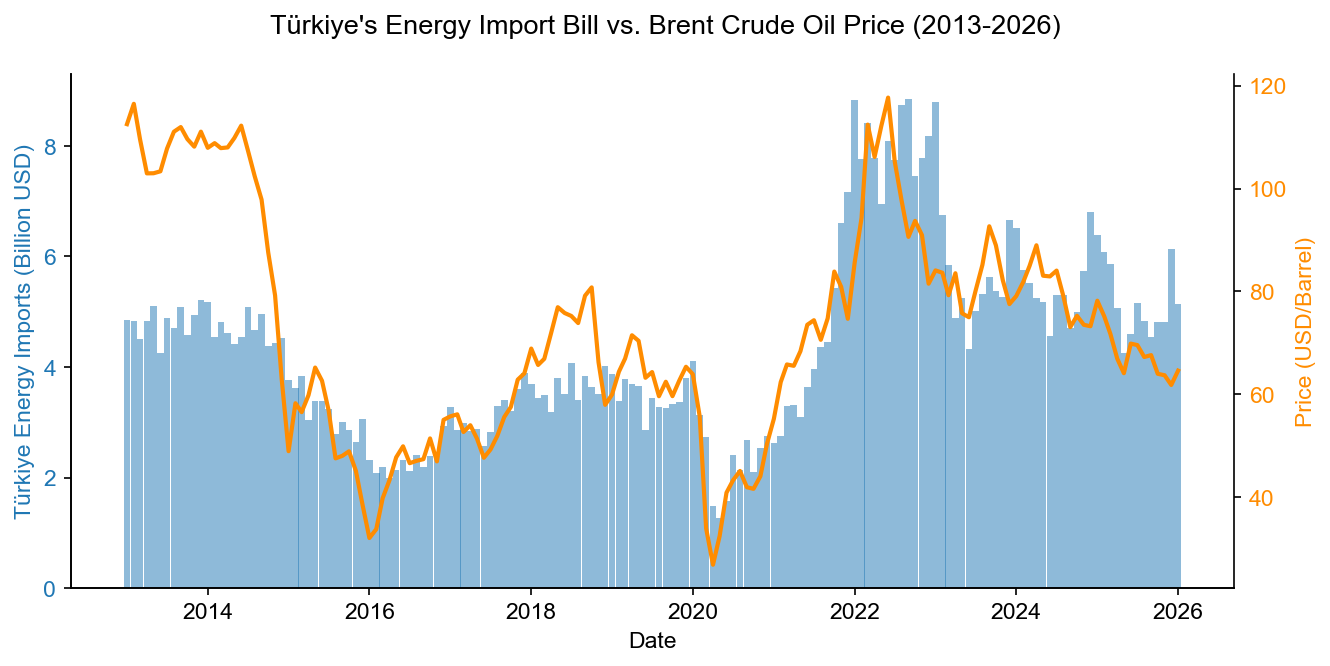

In [16]:
# Generate Oil Graph
plot_imports_vs_price(df_imports, df_oil, "Brent Crude Oil Price", "Price (USD/Barrel)", "darkorange", "price_vs_imports_oil.png")

## Figure 4: Arctic Supply Shock by Geological Province (USGS CARA)

While the Arctic holds 90 BBO and 1,669 TCF of gas, these resources are not distributed equally. To understand the geopolitical drivers (as argued by Morgunova), we must map the supply shock to specific geological provinces. 

The following code generates a dual stacked bar chart using data from Gautier et al. (2009) to visualize exactly which basins hold the oil versus the natural gas.


In [17]:
# --- DATA SETUP ---
# Data from Gautier et al. 2009 (USGS CARA) Fact Sheet
provinces = [
    "West Siberian Basin", 
    "Arctic Alaska Basin", 
    "East Barents Basin", 
    "East Greenland Rift",
    "Amerasia Basin",
    "Yenisey-Khatanga",
    "Other Provinces"
]

# Mean Undiscovered Oil (Billion Barrels) ~ Total: 90 BBO
oil_volumes = np.array([3.6, 29.9, 7.4, 8.9, 9.7, 5.5, 25.0]) 

# Mean Undiscovered Gas (Trillion Cubic Feet) ~ Total: 1669 TCF
gas_volumes = np.array([651.5, 221.4, 318.1, 86.2, 0.0, 99.6, 292.2]) 

# Distinct color palette mapping to the 7 provinces
basin_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#7f7f7f']


Saved C:\Users\sahin\OneDrive\Belgeler\programming\economy-thesis\report\Figures\arctic_provinces_stacked.png


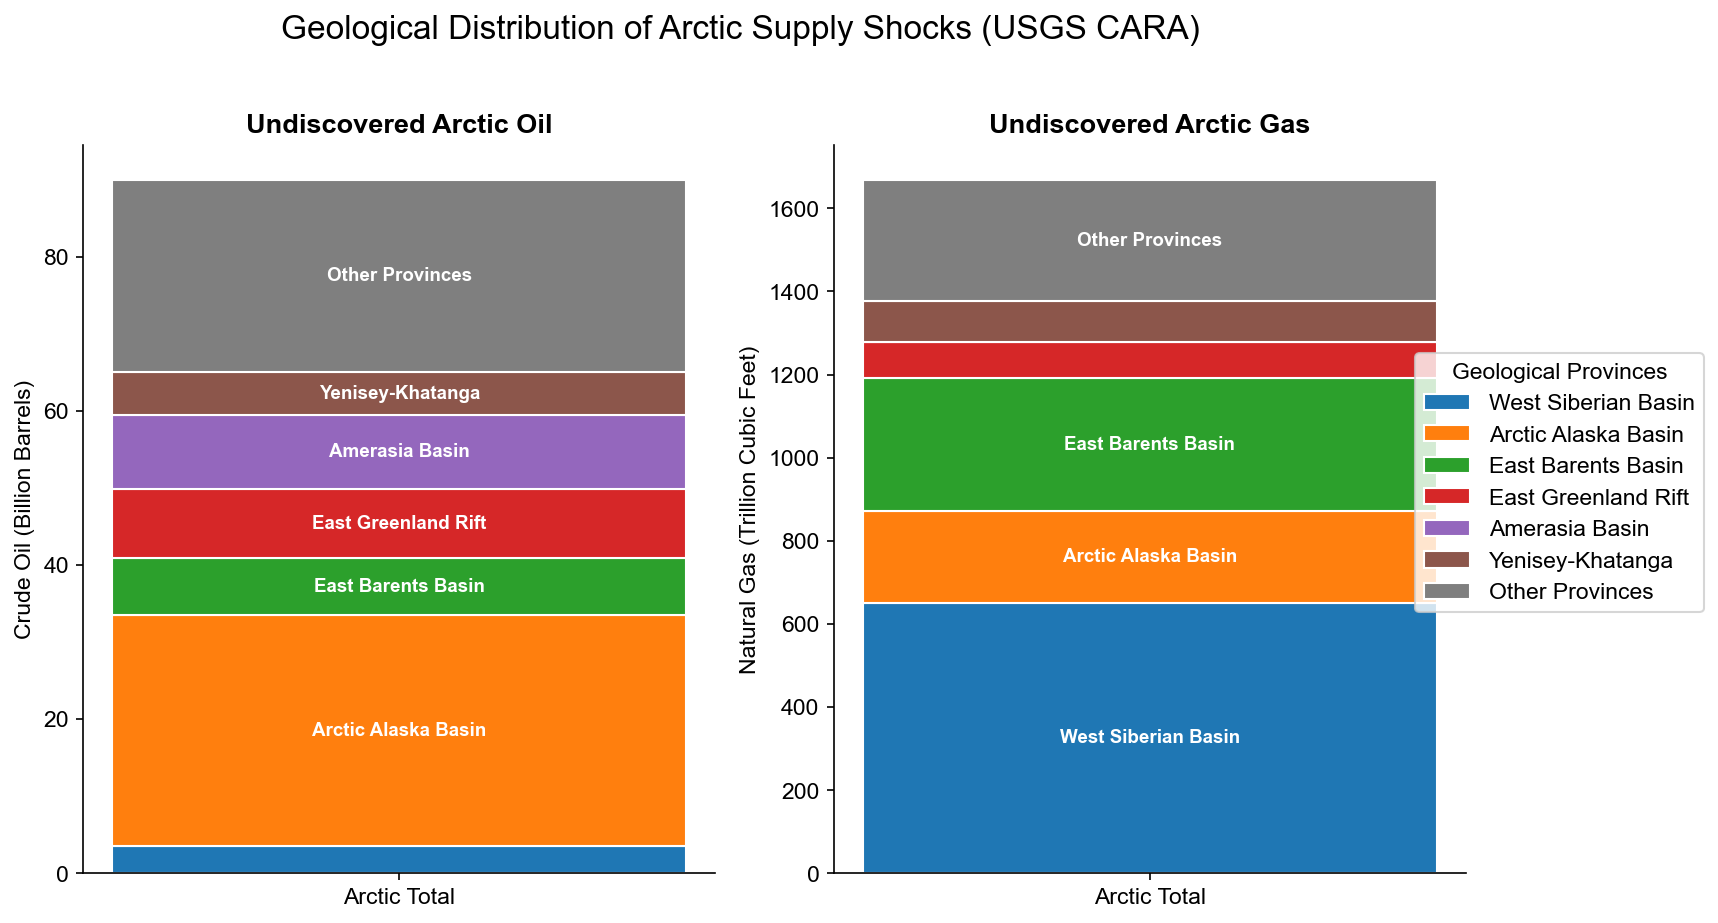

In [18]:
# --- PLOTTING FUNCTION ---
def plot_stacked_arctic_provinces():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
    
    # 1. Build the Stacked Bar for OIL (Left Axis)
    bottom_oil = 0
    for i in range(len(provinces)):
        ax1.bar("Arctic Total", oil_volumes[i], bottom=bottom_oil, color=basin_colors[i], 
                edgecolor='white', width=0.5, label=provinces[i])
        
        # Add a text label inside the bar if the chunk is large enough to read
        if oil_volumes[i] > 5:
            ax1.text(0, bottom_oil + (oil_volumes[i]/2), provinces[i], 
                     ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        bottom_oil += oil_volumes[i]
        
    ax1.set_title("Undiscovered Arctic Oil", fontsize=13, fontweight='bold')
    ax1.set_ylabel("Crude Oil (Billion Barrels)")
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # 2. Build the Stacked Bar for GAS (Right Axis)
    bottom_gas = 0
    for i in range(len(provinces)):
        ax2.bar("Arctic Total", gas_volumes[i], bottom=bottom_gas, color=basin_colors[i], 
                edgecolor='white', width=0.5)
        
        # Add a text label inside the bar if the chunk is large enough to read
        if gas_volumes[i] > 100:
            ax2.text(0, bottom_gas + (gas_volumes[i]/2), provinces[i], 
                     ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        bottom_gas += gas_volumes[i]

    ax2.set_title("Undiscovered Arctic Gas", fontsize=13, fontweight='bold')
    ax2.set_ylabel("Natural Gas (Trillion Cubic Feet)")
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # 3. Formatting and Export
    fig.suptitle("Geological Distribution of Arctic Supply Shocks (USGS CARA)", y=1.02, fontsize=16)
    
    # Place a single legend outside the plots
    fig.legend(provinces, loc='center right', bbox_to_anchor=(1.15, 0.5), title="Geological Provinces")
    
    plt.tight_layout()
    
    # Note: Make sure OUT_DIR is already defined in your notebook from the previous cells!
    out_path = os.path.join(OUT_DIR, "arctic_provinces_stacked.png")
    plt.savefig(out_path, format="png", bbox_inches='tight', dpi=150)
    print(f"Saved {out_path}")
    
    plt.show()

# Generate the plot
plot_stacked_arctic_provinces()


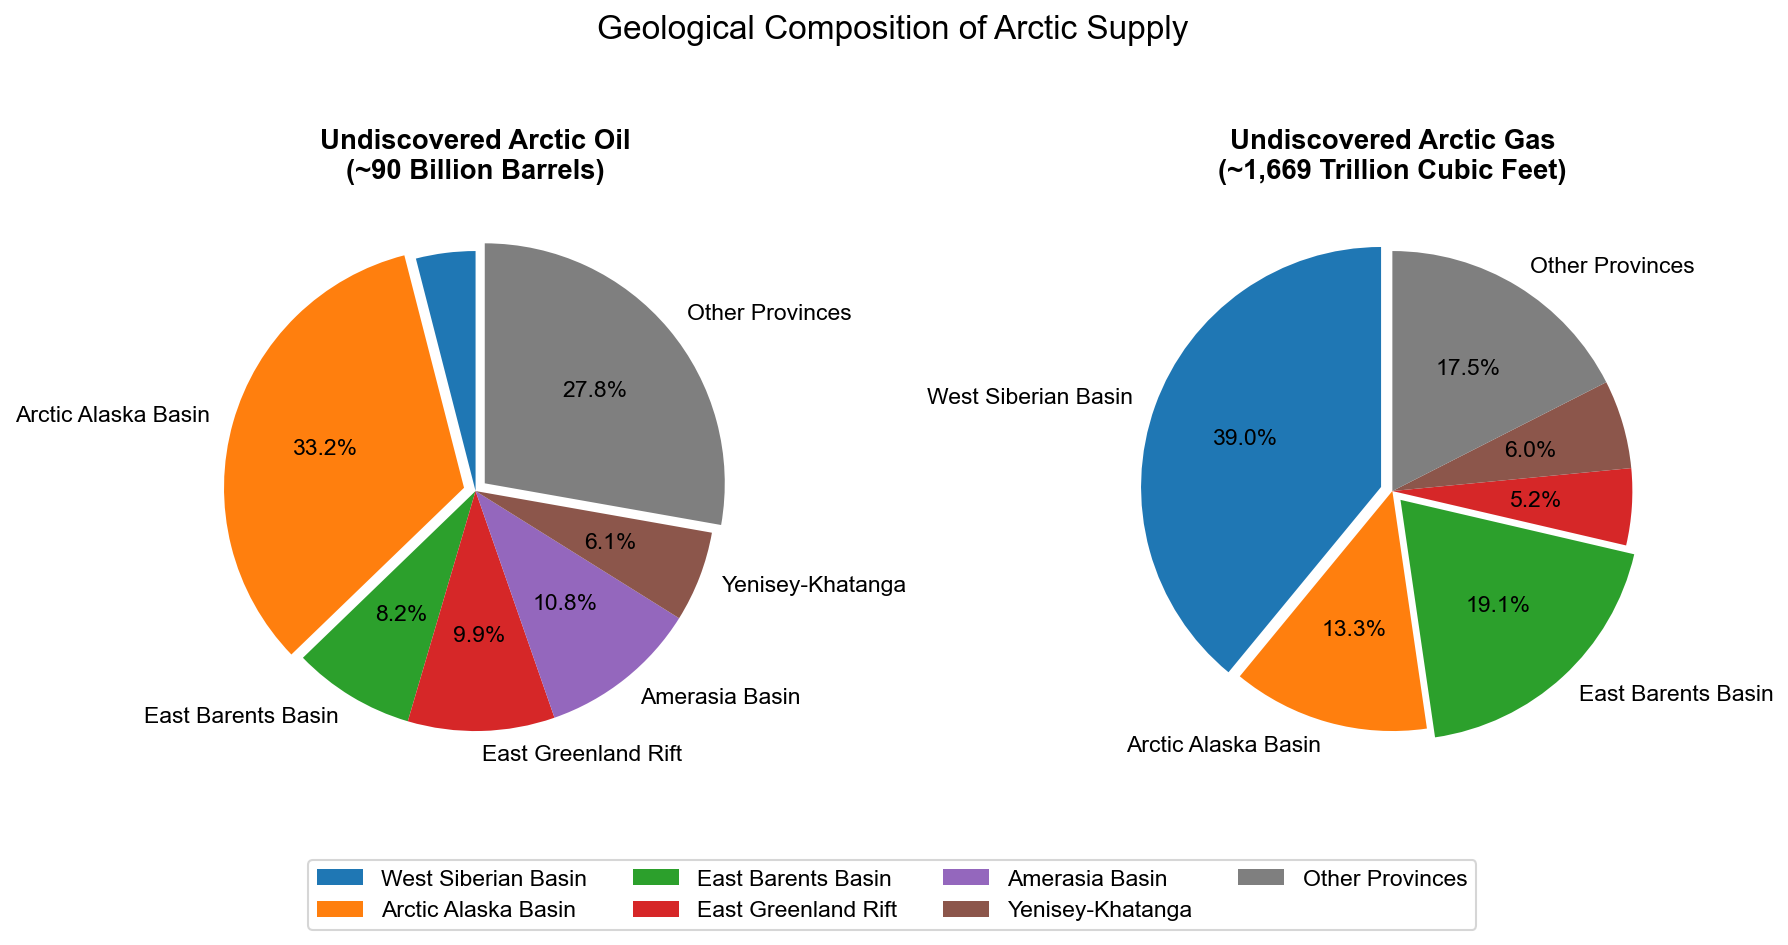

In [19]:
# --- ALTERNATIVE: PIE CHARTS FOR ARCTIC PROVINCES ---
def plot_arctic_provinces_pie():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # 1. Oil Pie Chart
    # 'Explode' the largest slices slightly outward for visual emphasis
    explode_oil = [0 if v < 20 else 0.05 for v in oil_volumes]
    
    ax1.pie(oil_volumes, labels=[p if v > 5 else '' for p, v in zip(provinces, oil_volumes)], 
            autopct=lambda pct: f"{pct:.1f}%" if pct > 5 else "", startangle=90, 
            colors=basin_colors, explode=explode_oil)
    ax1.set_title("Undiscovered Arctic Oil\n(~90 Billion Barrels)", fontweight='bold')

    # 2. Gas Pie Chart
    explode_gas = [0 if v < 300 else 0.05 for v in gas_volumes]
    
    ax2.pie(gas_volumes, labels=[p if v > 100 else '' for p, v in zip(provinces, gas_volumes)], 
            autopct=lambda pct: f"{pct:.1f}%" if pct > 5 else "", startangle=90, 
            colors=basin_colors, explode=explode_gas)
    ax2.set_title("Undiscovered Arctic Gas\n(~1,669 Trillion Cubic Feet)", fontweight='bold')
    
    fig.suptitle("Geological Composition of Arctic Supply", fontsize=16)
    
    # Add a unified legend to the bottom
    fig.legend(provinces, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout()
    plt.show()

plot_arctic_provinces_pie()


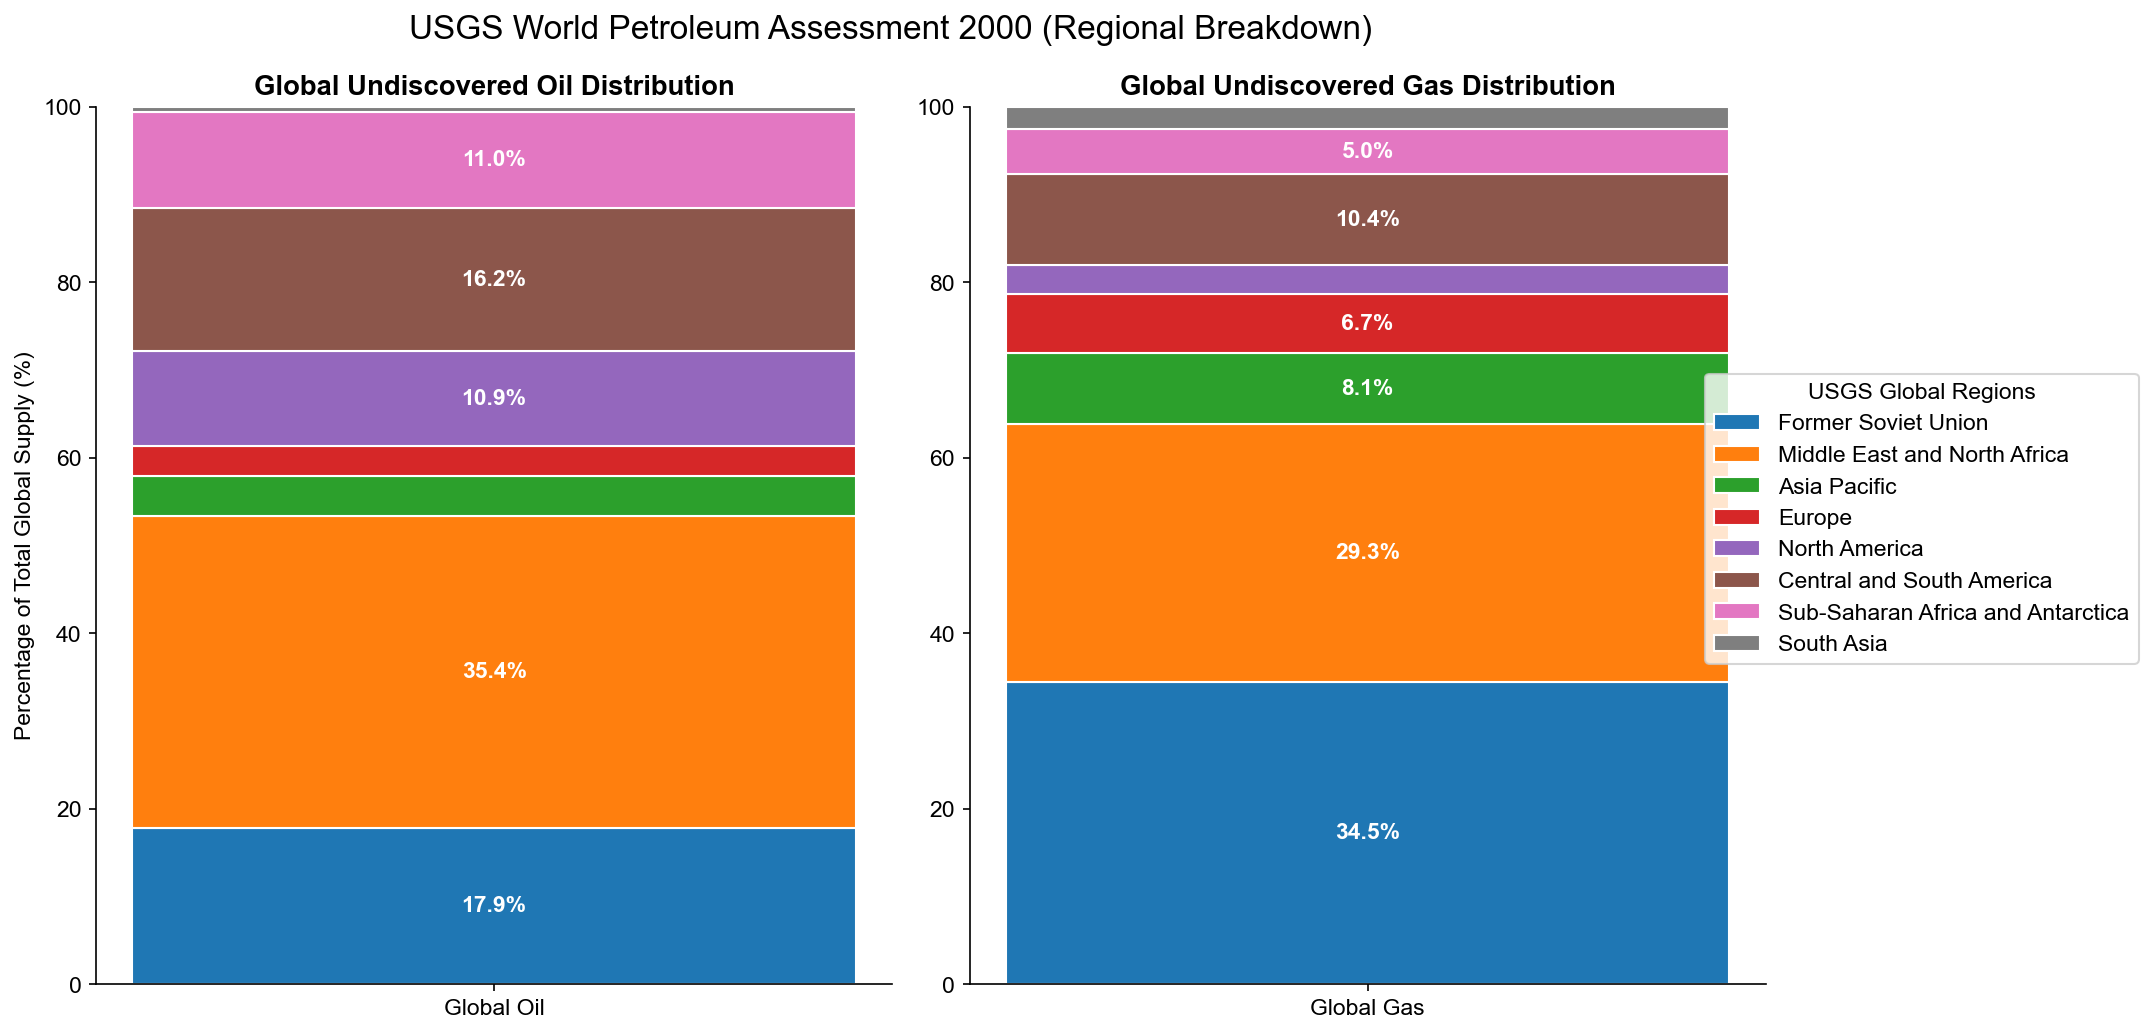

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_global_regions_from_file():
    # 1. Provide the exact path to your tabular file
    file_path = r'c:\Users\sahin\OneDrive\Belgeler\programming\economy-thesis\data\dds60tabular\sum_reg.tab'
    
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t')
    
    # 2. Clean the messy string numbers (remove quotes, commas, and spaces)
    def clean_column(col):
        # Convert to string, remove quotes and commas, strip whitespace, and convert to float
        cleaned = col.astype(str).str.replace('"', '', regex=False).str.replace(',', '', regex=False).str.strip()
        cleaned = cleaned.replace('NA', np.nan)
        return pd.to_numeric(cleaned, errors='coerce')
    
    df['Oil Mean (MMBO)'] = clean_column(df['Oil Mean (MMBO)'])
    df['Gas Mean (BCFG)'] = clean_column(df['Gas Mean (BCFG)'])
    
    # 3. Aggregate totals per Region
    # Oil only comes from 'oil' field rows. 
    # Gas comes from BOTH 'oil' fields (associated gas) and 'gas' fields (non-associated).
    oil_totals = df[df['Field Type'] == 'oil'].set_index('Region Name')['Oil Mean (MMBO)']
    gas_totals = df.groupby('Region Name')['Gas Mean (BCFG)'].sum()
    
    # Ensure they align perfectly
    regions = oil_totals.index.tolist()
    oil_values = oil_totals.values
    gas_values = gas_totals.reindex(regions).values
    
    # 4. Calculate Percentages for 100% Stacked Bar
    oil_pct = (oil_values / oil_values.sum()) * 100
    gas_pct = (gas_values / gas_values.sum()) * 100
    
    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
    
    # 8 distinct colors for the 8 regions
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Oil Stack
    bottom_oil = 0
    for i, region in enumerate(regions):
        ax1.bar("Global Oil", oil_pct[i], bottom=bottom_oil, color=colors[i], edgecolor='white', width=0.5, label=region)
        # Add text label if the chunk is big enough
        if oil_pct[i] > 5:
            ax1.text(0, bottom_oil + (oil_pct[i]/2), f"{oil_pct[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold')
        bottom_oil += oil_pct[i]
        
    ax1.set_title("Global Undiscovered Oil Distribution", fontweight='bold')
    ax1.set_ylabel("Percentage of Total Global Supply (%)")
    ax1.set_ylim(0, 100)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Gas Stack
    bottom_gas = 0
    for i, region in enumerate(regions):
        ax2.bar("Global Gas", gas_pct[i], bottom=bottom_gas, color=colors[i], edgecolor='white', width=0.5)
        # Add text label if the chunk is big enough
        if gas_pct[i] > 5:
            ax2.text(0, bottom_gas + (gas_pct[i]/2), f"{gas_pct[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold')
        bottom_gas += gas_pct[i]

    ax2.set_title("Global Undiscovered Gas Distribution", fontweight='bold')
    ax2.set_ylim(0, 100)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # Unified Legend
    fig.legend(regions, loc='center right', bbox_to_anchor=(1.2, 0.5), title="USGS Global Regions")
    fig.suptitle("USGS World Petroleum Assessment 2000 (Regional Breakdown)", fontsize=16)
    
    plt.tight_layout()
    plt.show()

# Run the function!
plot_global_regions_from_file()
